In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

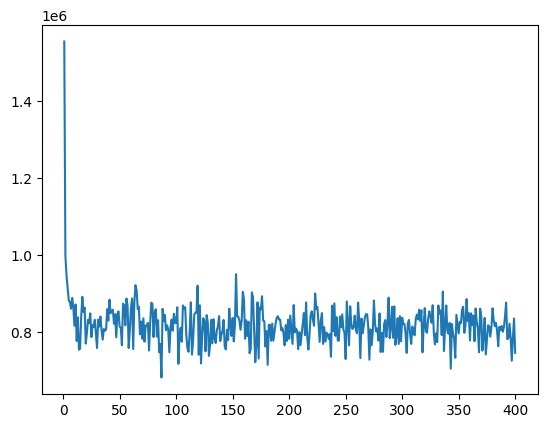

In [3]:
df = pd.read_csv('run/cosmos_dm_1900_3/Train.csv')

plt.plot(df['Epoch'], df['Loss'])
plt.savefig('temp.jpg', bbox_inches='tight', dpi=300)

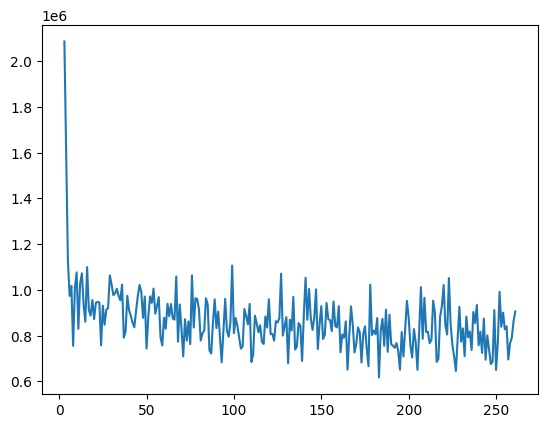

In [2]:
df = pd.read_csv('run/cosmos_dm_1900_2/Train.csv')

plt.plot(df['Epoch'], df['Loss'])
plt.savefig('run/cosmos_dm_1900_2/train_history.jpg', dpi=200, bbox_inches='tight')

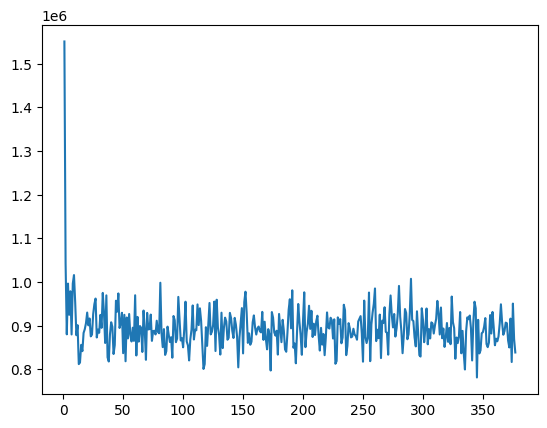

In [3]:
df = pd.read_csv('run/cosmos_halo_1900/Train.csv')

plt.plot(df['Epoch'], df['Loss'])
plt.savefig('run/cosmos_halo_1900/train_history.jpg', dpi=200, bbox_inches='tight')

In [7]:
import os
import zipfile
from tqdm import tqdm
from pathlib import Path

def zip_npy_files(
    source_dir, output_dir, zip_filename="npy_archive.zip", 
    recursive=False, start=0, end=1999
):
    """
    Scans a directory for .npy files and adds them to a zip archive in a destination folder.

    Args:
        source_dir (str or Path): The directory to search for .npy files.
        output_dir (str or Path): The directory where the zip file will be saved.
        zip_filename (str): The name of the resulting zip file.
        recursive (bool): If True, searches subdirectories as well. Default is False.
    
    Returns:
        str: The full path to the created zip file.
    """
    source_path = Path(source_dir)
    output_path = Path(output_dir)
    
    # Ensure source exists
    if not source_path.exists():
        raise FileNotFoundError(f"Source directory not found: {source_dir}")

    # Create output directory if it doesn't exist
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Define the full path for the zip file
    final_zip_path = output_path / zip_filename
    
    # Determine usage of glob (shallow) or rglob (recursive)
    pattern = '*.npy'
    files_to_zip = list(source_path.rglob(pattern)) if recursive else list(source_path.glob(pattern))

    if not files_to_zip:
        print(f"No .npy files found in {source_dir}")
        return None

    print(f"Found {len(files_to_zip)} .npy files. Zipping {start} to {end} indices...")
    files_to_zip = files_to_zip[start:end+1]

    try:
        # Open zip file in write mode with compression
        with zipfile.ZipFile(final_zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for file_path in tqdm(files_to_zip):
                # arcname is the name the file will have inside the zip.
                # using relative_to ensures we don't zip the full absolute path structure
                arcname = file_path.relative_to(source_path)
                zipf.write(file_path, arcname=arcname)
                # print(f"Added: {arcname}")
                
        print(f"Successfully created: {final_zip_path}")
        return str(final_zip_path)

    except Exception as e:
        print(f"An error occurred during zipping: {e}")
        return None


In [13]:
# Create dummy data for demonstration purposes
import numpy as np

# 1. Setup dummy source folder
src = Path("./Dataset/halo_LH_128/")

# 3. Define destination
dst = Path(".")

# 4. Run the function
start, end = 1501, 1999
zip_npy_files(
    source_dir=src, 
    output_dir=dst, 
    zip_filename=f"halo_{start}_{end}.zip",
    recursive=False,
    start=start, end=end
)

Found 2000 .npy files. Zipping 1501 to 1999 indices...


100%|██████████| 499/499 [03:33<00:00,  2.34it/s]

Successfully created: halo_1501_1999.zip


'halo_1501_1999.zip'